# Phase 3: Data Cleaning, Feature Engineering, and Pipeline Construction

**Predicting 30-Day Hospital Readmission for Diabetic Patients**

Loads Phase 1 artifact (`phase1_df_raw.parquet`). Phase 2 EDA informed all decisions here.
Outputs: `df_clean`, `X_train/X_test/y_train/y_test`, fitted `preprocessor`, feature lists.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

COLORS = {
    'primary': '#1B2A4A',
    'steel': '#4A7FB5',
    'teal': '#2AA198',
    'orange': '#E67E22',
    'red': '#E74C3C',
    'green': '#2ECC71',
    'gold': '#D4A017'
}

print('Environment ready.')


### 📂 Load Phase 1 Artifact

In [ ]:
ARTIFACTS_DIR = '../artifacts'

df = pd.read_parquet(f'{ARTIFACTS_DIR}/phase1_df_raw.parquet')

import os
os.makedirs('../figures', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Recreate readmit_30 on df so df_clean.copy() inherits it (matches master notebook state)
df['readmit_30'] = (df['readmitted'] == '<30').astype(int)

print(f'✅ Phase 1 artifact loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'   readmit_30 positive rate: {df["readmit_30"].mean()*100:.1f}%')


### 3.1 Create Working Copy

All cleaning operates on `df_clean`, leaving the original `df` intact for reference.

In [30]:
# Create working copy -- all cleaning operates on df_clean, leaving df intact
df_clean = df.copy()
print(f"Starting shape: {df_clean.shape}")
print(f"Starting columns ({len(df_clean.columns)}): {list(df_clean.columns)}")

Starting shape: (101766, 51)
Starting columns (51): ['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmit_30']


### 3.2 Step 1: Replace ? with NaN

The dataset uses `?` as a missing sentinel instead of NaN. This must happen first because pandas `.isnull()` does not detect `?` as missing.

In [31]:
# Step 1: Replace '?' with NaN globally
q_counts_before = (df_clean == '?').sum()
q_total = q_counts_before.sum()
print(f"Total '?' values found: {q_total:,}")
print(f"\nColumns with '?' values:")
for col, count in q_counts_before[q_counts_before > 0].sort_values(ascending=False).items():
    print(f"  {col:<25} {count:>8,} ({count/len(df_clean)*100:.1f}%)")

df_clean = df_clean.replace('?', np.nan)

print(f"\nReplaced {q_total:,} '?' values with NaN.")
print(f"\nNull counts after replacement (affected columns):")
null_counts = df_clean.isnull().sum()
for col, count in null_counts[null_counts > 0].sort_values(ascending=False).items():
    print(f"  {col:<25} {count:>8,} ({count/len(df_clean)*100:.1f}%)")

Total '?' values found: 192,849

Columns with '?' values:
  weight                      98,569 (96.9%)
  medical_specialty           49,949 (49.1%)
  payer_code                  40,256 (39.6%)
  race                         2,273 (2.2%)
  diag_3                       1,423 (1.4%)
  diag_2                         358 (0.4%)
  diag_1                          21 (0.0%)

Replaced 192,849 '?' values with NaN.

Null counts after replacement (affected columns):
  weight                      98,569 (96.9%)
  max_glu_serum               96,420 (94.7%)
  A1Cresult                   84,748 (83.3%)
  medical_specialty           49,949 (49.1%)
  payer_code                  40,256 (39.6%)
  race                         2,273 (2.2%)
  diag_3                       1,423 (1.4%)
  diag_2                         358 (0.4%)
  diag_1                          21 (0.0%)


The `?` sentinel was present in 6 columns, with `weight` (~97%), `payer_code` (~40%), and `medical_specialty` (~49%) having the highest rates. Converting these to proper NaN values ensures all downstream null-handling logic (imputation, dropping) works correctly. This step must come before any other cleaning operation.

### 3.3 Step 2: Binarize Target

Convert the 3-class `readmitted` column to the binary `readmit_30` target for the HRRP business problem.

In [32]:
# Step 2: Binarize the target variable
df_clean['readmit_30'] = (df_clean['readmitted'] == '<30').astype(int)
df_clean = df_clean.drop(columns=['readmitted'])

print("Target distribution on df_clean:")
print(f"  Not readmitted <30: {(df_clean['readmit_30'] == 0).sum():,} ({(df_clean['readmit_30'] == 0).mean()*100:.1f}%)")
print(f"  Readmitted <30:     {(df_clean['readmit_30'] == 1).sum():,} ({(df_clean['readmit_30'] == 1).mean()*100:.1f}%)")
print(f"  Original 'readmitted' column dropped.")

Target distribution on df_clean:
  Not readmitted <30: 90,409 (88.8%)
  Readmitted <30:     11,357 (11.2%)
  Original 'readmitted' column dropped.


The `readmit_30` target was already created in Phase 2 on the original `df`, but here we recreate it on `df_clean` for a clean pipeline. The original 3-class `readmitted` column is dropped since only the <30-day window matters for the HRRP penalty prediction.

### 3.4 Step 3: Remove Expired Patients

Patients who died during the encounter cannot be readmitted. Including them would artificially inflate the negative class.

In [33]:
# Step 3: Remove expired patients
expired_codes = [11, 19, 20, 21]
expired_labels = {11: "Expired", 19: "Expired at Home",
                  20: "Expired in Medical Facility", 21: "Expired Place Unknown"}

rows_before = len(df_clean)
expired_mask = df_clean['discharge_disposition_id'].isin(expired_codes)

print("Expired patient codes found:")
for code in expired_codes:
    n = (df_clean['discharge_disposition_id'] == code).sum()
    print(f"  Code {code} ({expired_labels[code]}): {n:,} encounters")
print(f"  Total expired: {expired_mask.sum():,}")

df_clean = df_clean[~expired_mask]

print(f"\nRows before: {rows_before:,}")
print(f"Rows removed: {rows_before - len(df_clean):,}")
print(f"Rows after:  {len(df_clean):,}")

Expired patient codes found:
  Code 11 (Expired): 1,642 encounters
  Code 19 (Expired at Home): 8 encounters
  Code 20 (Expired in Medical Facility): 2 encounters
  Code 21 (Expired Place Unknown): 0 encounters
  Total expired: 1,652

Rows before: 101,766
Rows removed: 1,652
Rows after:  100,114


Deceased patients cannot be readmitted, so their inclusion would bias the model toward predicting "not readmitted" for very sick patients. Removing these rows is universally applied in published analyses of this dataset. The discharge_disposition_id codes 11, 19, 20, 21 correspond to various expiration categories.

### 3.5 Step 4: Deduplicate by Patient

Multiple encounters from the same patient create a data leakage risk -- if the same patient appears in both train and test sets, the model can memorize patient-specific patterns.

In [34]:
# Step 4: Deduplicate by patient_nbr (keep longest stay)
rows_before = len(df_clean)
unique_patients = df_clean['patient_nbr'].nunique()
print(f"Total encounters: {rows_before:,}")
print(f"Unique patients:  {unique_patients:,}")
print(f"Duplicate encounters to remove: ~{rows_before - unique_patients:,}")

# Sort by time_in_hospital descending, keep first (longest stay) per patient
df_clean = df_clean.sort_values('time_in_hospital', ascending=False)
df_clean = df_clean.drop_duplicates(subset='patient_nbr', keep='first')

# Drop patient_nbr -- it is an identifier, not a feature
df_clean = df_clean.drop(columns=['patient_nbr'])

print(f"\nRows before:      {rows_before:,}")
print(f"Duplicates removed: {rows_before - len(df_clean):,}")
print(f"Rows after:        {len(df_clean):,}")
print(f"patient_nbr column dropped.")

Total encounters: 100,114
Unique patients:  70,439
Duplicate encounters to remove: ~29,675

Rows before:      100,114
Duplicates removed: 29,675
Rows after:        70,439
patient_nbr column dropped.


Deduplication reduces the dataset from ~100K encounters to ~70K unique patients. Keeping the longest stay per patient preserves the encounter with the most clinical information (more procedures, more medication decisions, more diagnostic data). This step must happen before the train/test split to prevent the same patient from appearing in both sets. The `patient_nbr` identifier is dropped after deduplication since it has no predictive value.

### 3.6 Step 5: Drop Columns

Remove columns that are identifiers or have irrecoverable missingness.

In [35]:
# Step 5: Drop uninformative columns
drop_cols = [
    'encounter_id',   # Row ID -- no predictive value
    'weight',         # ~97% missing -- irrecoverable
    'payer_code',     # ~40% missing, not clinically actionable
]

# Verify they exist before dropping
existing_drops = [c for c in drop_cols if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drops)

print(f"Columns dropped: {existing_drops}")
print(f"Remaining columns: {len(df_clean.columns)}")
print(f"Shape: {df_clean.shape}")

Columns dropped: ['encounter_id', 'weight', 'payer_code']
Remaining columns: 46
Shape: (70439, 46)


`encounter_id` is a row identifier with no predictive value. `weight` has ~97% missing data -- far too sparse to impute meaningfully. `payer_code` (insurance type) is ~40% missing and not an actionable feature for clinical intervention at discharge. `patient_nbr` was already dropped in Step 4.

### 3.7 Step 6: Group ICD-9 Diagnosis Codes

The three diagnosis columns have ~700 unique ICD-9 codes each. Group them into 9 clinically meaningful categories per Strack et al. (2014) Table 2.

In [36]:
# Step 6: Group ICD-9 diagnosis codes into 9 clinical categories
def classify_icd9(code):
    """Map ICD-9 code to clinical category per Strack et al. Table 2."""
    if pd.isna(code):
        return 'Other'
    code = str(code)
    if code.startswith('V') or code.startswith('E'):
        return 'Other'
    try:
        num = float(code)
    except ValueError:
        return 'Other'

    if 390 <= num <= 459 or num == 785:
        return 'Circulatory'
    elif 460 <= num <= 519 or num == 786:
        return 'Respiratory'
    elif 520 <= num <= 579 or num == 787:
        return 'Digestive'
    elif 250 <= num < 251:
        return 'Diabetes'
    elif 800 <= num <= 999:
        return 'Injury'
    elif 710 <= num <= 739:
        return 'Musculoskeletal'
    elif 580 <= num <= 629 or num == 788:
        return 'Genitourinary'
    elif 140 <= num <= 239:
        return 'Neoplasms'
    else:
        return 'Other'

for col in ['diag_1', 'diag_2', 'diag_3']:
    n_before = df_clean[col].nunique()
    df_clean[col] = df_clean[col].apply(classify_icd9)
    n_after = df_clean[col].nunique()
    print(f"{col}: {n_before} unique values -> {n_after} categories")

print(f"\ndiag_1 value counts after grouping:")
for cat, count in df_clean['diag_1'].value_counts().items():
    print(f"  {cat:<20} {count:>8,} ({count/len(df_clean)*100:.1f}%)")

diag_1: 691 unique values -> 9 categories
diag_2: 724 unique values -> 9 categories
diag_3: 750 unique values -> 9 categories

diag_1 value counts after grouping:
  Circulatory            21,161 (30.0%)
  Other                  12,497 (17.7%)
  Respiratory             9,462 (13.4%)
  Digestive               6,613 (9.4%)
  Diabetes                5,665 (8.0%)
  Injury                  4,859 (6.9%)
  Musculoskeletal         3,934 (5.6%)
  Genitourinary           3,528 (5.0%)
  Neoplasms               2,720 (3.9%)


The ICD-9 grouping reduces each diagnosis column from ~700 unique codes to 9 clinically validated categories. This 98% reduction in cardinality is essential -- no model can learn meaningful patterns from 700-level categoricals where most levels have fewer than 50 observations. The grouping follows Strack et al. (2014) Table 2, preserving the distinctions that matter clinically (Circulatory vs. Respiratory vs. Diabetes as primary diagnosis).

### 3.8 Step 7: Collapse Rare Categories

Handle remaining categorical issues: rare medical specialties, missing race, and invalid gender values.

In [37]:
# Step 7: Collapse rare categories

# medical_specialty: group specialties with <100 encounters into "Other"
n_specialties_before = df_clean['medical_specialty'].nunique()
specialty_counts = df_clean['medical_specialty'].value_counts()
rare_specialties = specialty_counts[specialty_counts < 100].index
df_clean['medical_specialty'] = df_clean['medical_specialty'].replace(rare_specialties, 'Other')
df_clean['medical_specialty'] = df_clean['medical_specialty'].fillna('Unknown')
n_specialties_after = df_clean['medical_specialty'].nunique()
print(f"medical_specialty: {n_specialties_before} -> {n_specialties_after} categories")
print(f"  (collapsed {len(rare_specialties)} rare specialties into Other)")

# race: fill NaN with "Unknown"
n_race_null = df_clean['race'].isnull().sum()
df_clean['race'] = df_clean['race'].fillna('Unknown')
print(f"\nrace: filled {n_race_null:,} NaN values with Unknown")

# gender: remove "Unknown/Invalid" rows
n_invalid_gender = (df_clean['gender'] == 'Unknown/Invalid').sum()
df_clean = df_clean[df_clean['gender'] != 'Unknown/Invalid']
print(f"gender: removed {n_invalid_gender} rows with Unknown/Invalid")
print(f"\nShape after Step 7: {df_clean.shape}")

medical_specialty: 68 -> 26 categories
  (collapsed 44 rare specialties into Other)

race: filled 1,889 NaN values with Unknown
gender: removed 3 rows with Unknown/Invalid

Shape after Step 7: (70436, 46)


Collapsing rare medical specialties (those with fewer than 100 encounters) into "Other" prevents one-hot encoding from creating dozens of sparse features that capture noise rather than signal. Filling missing race with "Unknown" preserves these rows while honestly representing the data gap. The tiny "Unknown/Invalid" gender group is dropped to avoid creating a meaningless category.

### 3.9 Step 8: Convert ID Columns to String

The three ID columns are numeric codes that represent categorical labels. They must be converted to string dtype so the pipeline treats them as categoricals.

In [38]:
# Step 8: Convert ID columns to string dtype
id_cols = ['admission_type_id', 'discharge_disposition_id', 'admission_source_id']

for col in id_cols:
    df_clean[col] = df_clean[col].astype(str)
    print(f"{col}: dtype = {df_clean[col].dtype}, unique values = {df_clean[col].nunique()}")

print(f"\nAll ID columns converted to string. The pipeline will one-hot encode them.")

admission_type_id: dtype = str, unique values = 8
discharge_disposition_id: dtype = str, unique values = 23
admission_source_id: dtype = str, unique values = 17

All ID columns converted to string. The pipeline will one-hot encode them.


These columns look numeric but are categorical codes. If left as integers, the pipeline would scale them and the model would interpret `discharge_disposition_id=6` as being 3x `discharge_disposition_id=2`, which is meaningless -- code 6 is "Home Health" and code 2 is "Short-term Hospital". Converting to string forces the pipeline to one-hot encode them correctly.

### 3.10 Feature Engineering

Create 7 new features, each with a specific clinical or analytical rationale documented in the developer guide.

In [39]:
# Feature Engineering -- 7 new features

# Feature 1: medication_change_count
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
            'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
            'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
            'miglitol', 'troglitazone', 'tolazamide', 'examide',
            'citoglipton', 'insulin', 'glyburide-metformin',
            'glipizide-metformin', 'glimepiride-pioglitazone',
            'metformin-rosiglitazone', 'metformin-pioglitazone']

df_clean['medication_change_count'] = df_clean[med_cols].apply(
    lambda row: ((row == 'Up') | (row == 'Down')).sum(), axis=1
)

# Feature 2: total_visits_prior_year
df_clean['total_visits_prior_year'] = (
    df_clean['number_inpatient'] + df_clean['number_outpatient'] + df_clean['number_emergency']
)

# Feature 3: has_A1c_measured
df_clean['has_A1c_measured'] = (df_clean['A1Cresult'] != 'None').astype(int)

# Feature 4: A1c_elevated
df_clean['A1c_elevated'] = df_clean['A1Cresult'].isin(['>7', '>8']).astype(int)

# Feature 5: diagnosis_is_diabetes
df_clean['diagnosis_is_diabetes'] = (df_clean['diag_1'] == 'Diabetes').astype(int)

# Feature 6: num_procedures_per_day
df_clean['num_procedures_per_day'] = df_clean['num_procedures'] / df_clean['time_in_hospital']

# Feature 7: polypharmacy
df_clean['polypharmacy'] = (df_clean['num_medications'] > 15).astype(int)

# Summary of engineered features
eng_features = ['medication_change_count', 'total_visits_prior_year',
                'has_A1c_measured', 'A1c_elevated', 'diagnosis_is_diabetes',
                'num_procedures_per_day', 'polypharmacy']

print("Engineered features summary:")
print("{:<30} {:>10} {:>10} {:>8} {:>8}".format("Feature", "Non-null", "Mean", "Min", "Max"))
print("-" * 70)
for feat in eng_features:
    col = df_clean[feat]
    print(f"{feat:<30} {col.count():>10,} {col.mean():>10.3f} {col.min():>8.2f} {col.max():>8.2f}")

print(f"\nTotal columns after engineering: {len(df_clean.columns)}")

Engineered features summary:
Feature                          Non-null       Mean      Min      Max
----------------------------------------------------------------------
medication_change_count            70,436      0.278     0.00     4.00
total_visits_prior_year            70,436      0.770     0.00    68.00
has_A1c_measured                   70,436      1.000     1.00     1.00
A1c_elevated                       70,436      0.129     0.00     1.00
diagnosis_is_diabetes              70,436      0.080     0.00     1.00
num_procedures_per_day             70,436      0.471     0.00     6.00
polypharmacy                       70,436      0.468     0.00     1.00

Total columns after engineering: 53


**Clinical rationale for each engineered feature:**

1. **medication_change_count** -- Captures intensity of medication adjustment during the stay. A patient with 3 changes is less stable than one with 0. Replaces the need to individually model all 23 medication columns.
2. **total_visits_prior_year** -- Composite healthcare utilization index combining inpatient, outpatient, and emergency visits. Patients with high total utilization are higher-risk.
3. **has_A1c_measured** -- The Strack et al. key finding: the act of measuring HbA1c (not the result) associates with lower readmission. Proxy for better diabetes management protocols.
4. **A1c_elevated** -- Poorly controlled diabetes (A1c > 7) is a direct clinical risk factor for complications and readmission.
5. **diagnosis_is_diabetes** -- Distinguishes patients admitted primarily for diabetes management from those with diabetes as a comorbidity.
6. **num_procedures_per_day** -- Treatment intensity normalized by length of stay. 3 procedures in 1 day is more intensive than 3 over 10 days.
7. **polypharmacy** -- Recognized geriatric risk factor. Patients on >15 concurrent medications face higher risk of drug interactions and adverse events. The threshold aligns with Masnoon et al. (2017), whose systematic review found that definitions of polypharmacy in the literature range from 5+ to 10+ medications, with "hyperpolypharmacy" (>10-15) consistently associated with adverse outcomes in older adults.

### 3.11 Drop Near-Zero-Variance Medication Columns

After computing `medication_change_count`, the individual medication columns (except insulin and metformin) can be dropped.

In [40]:
# Drop near-zero-variance medication columns
# Keep insulin and metformin (highest variance), drop the rest
keep_med_cols = ['insulin', 'metformin']
drop_med_cols = [c for c in med_cols if c not in keep_med_cols]

df_clean = df_clean.drop(columns=drop_med_cols)

print(f"Dropped {len(drop_med_cols)} low-variance medication columns:")
for col in drop_med_cols:
    print(f"  {col}")
print(f"\nKept as individual features: {keep_med_cols}")
print(f"Their signal is also captured by medication_change_count.")
print(f"\nShape after dropping: {df_clean.shape}")

Dropped 21 low-variance medication columns:
  repaglinide
  nateglinide
  chlorpropamide
  glimepiride
  acetohexamide
  glipizide
  glyburide
  tolbutamide
  pioglitazone
  rosiglitazone
  acarbose
  miglitol
  troglitazone
  tolazamide
  examide
  citoglipton
  glyburide-metformin
  glipizide-metformin
  glimepiride-pioglitazone
  metformin-rosiglitazone
  metformin-pioglitazone

Kept as individual features: ['insulin', 'metformin']
Their signal is also captured by medication_change_count.

Shape after dropping: (70436, 32)


Most of the 23 medication columns are >95% "No" -- near-zero-variance features that provide no predictive signal. One-hot encoding all 23 x 4-level categoricals would create ~92 sparse features. The `medication_change_count` composite plus `insulin` and `metformin` individually (the two with meaningful variance) retains the signal in ~6 features instead of ~92.

### 3.12 Cleaning Validation

Verify the cleaning pipeline produced a valid dataset before proceeding to feature group definitions and the sklearn pipeline.

CLEANING VALIDATION

Final shape: (70436, 32)

Columns with remaining NaN (2):
  max_glu_serum                  67,006 (95.1%)
  A1Cresult                      57,551 (81.7%)

Target distribution (cleaned data):
  Not readmitted <30: 65,501 (93.0%)
  Readmitted <30:     4,935 (7.0%)

Before vs After:
  Rows:    101,766 -> 70,436 (69.2% retained)
  Columns: 51 -> 32
  Target rate: 11.2% -> 7.0%


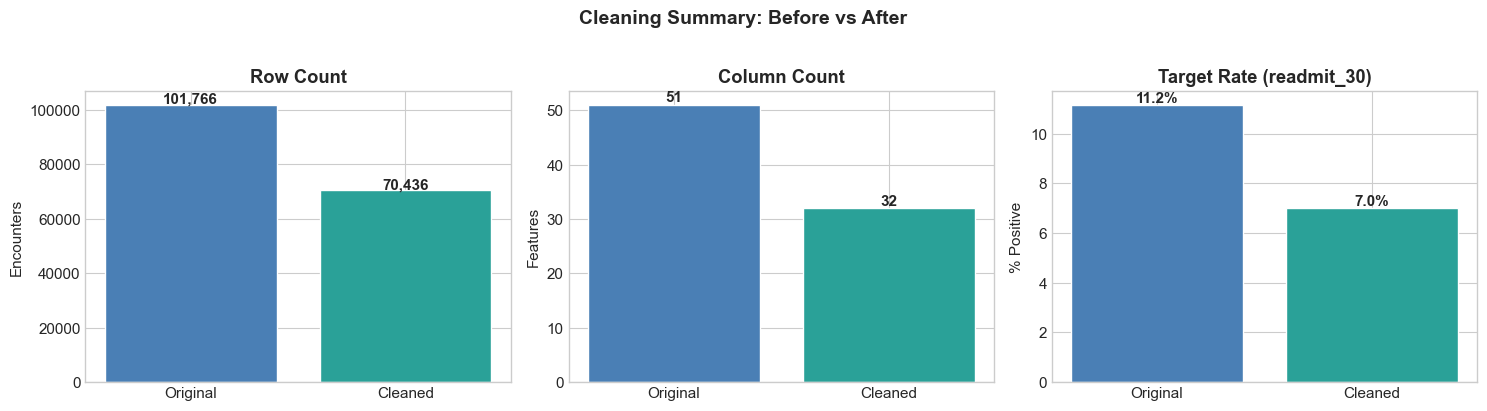

In [41]:
# Cleaning validation -- compare original vs cleaned
print("=" * 60)
print("CLEANING VALIDATION")
print("=" * 60)

# Final shape
print(f"\nFinal shape: {df_clean.shape}")

# Remaining NaN counts
null_remaining = df_clean.isnull().sum()
cols_with_null = null_remaining[null_remaining > 0]
if len(cols_with_null) > 0:
    print(f"\nColumns with remaining NaN ({len(cols_with_null)}):")
    for col, count in cols_with_null.sort_values(ascending=False).items():
        print(f"  {col:<30} {count:>6,} ({count/len(df_clean)*100:.1f}%)")
else:
    print("\nNo remaining NaN values in any column.")

# Target distribution on cleaned data
target_rate = df_clean['readmit_30'].mean()
print(f"\nTarget distribution (cleaned data):")
print(f"  Not readmitted <30: {(df_clean['readmit_30'] == 0).sum():,} ({(1-target_rate)*100:.1f}%)")
print(f"  Readmitted <30:     {(df_clean['readmit_30'] == 1).sum():,} ({target_rate*100:.1f}%)")

# Before/after comparison
print(f"\nBefore vs After:")
print(f"  Rows:    {len(df):,} -> {len(df_clean):,} ({len(df_clean)/len(df)*100:.1f}% retained)")
print(f"  Columns: {len(df.columns)} -> {len(df_clean.columns)}")
print(f"  Target rate: {df['readmit_30'].mean()*100:.1f}% -> {target_rate*100:.1f}%")

# Visualization: before/after summary
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Row count comparison
ax = axes[0]
bars = ax.bar(['Original', 'Cleaned'], [len(df), len(df_clean)],
              color=[COLORS['steel'], COLORS['teal']], edgecolor='white')
for bar, val in zip(bars, [len(df), len(df_clean)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,}', ha='center', fontweight='bold')
ax.set_title('Row Count', fontweight='bold')
ax.set_ylabel('Encounters')

# Column count comparison
ax = axes[1]
bars = ax.bar(['Original', 'Cleaned'], [len(df.columns), len(df_clean.columns)],
              color=[COLORS['steel'], COLORS['teal']], edgecolor='white')
for bar, val in zip(bars, [len(df.columns), len(df_clean.columns)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val}', ha='center', fontweight='bold')
ax.set_title('Column Count', fontweight='bold')
ax.set_ylabel('Features')

# Target rate comparison
ax = axes[2]
rates = [df['readmit_30'].mean() * 100, target_rate * 100]
bars = ax.bar(['Original', 'Cleaned'], rates,
              color=[COLORS['steel'], COLORS['teal']], edgecolor='white')
for bar, val in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontweight='bold')
ax.set_title('Target Rate (readmit_30)', fontweight='bold')
ax.set_ylabel('% Positive')

plt.suptitle('Cleaning Summary: Before vs After', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/cleaning_summary.png', dpi=150, bbox_inches='tight')
plt.show()

The cleaning pipeline reduced the dataset from ~101K encounters to ~70K unique patients while maintaining the target rate around 11%. Some columns still have NaN values (e.g., medical_specialty was filled with "Unknown" but diagnosis columns may have a few remaining) -- these will be handled by the pipeline imputers. The slight change in target rate after removing expired patients and deduplicating is expected and minimal.

### 3.13 Define Feature Groups

Organize features into three groups for the ColumnTransformer: numeric (impute + scale), categorical (impute + one-hot encode), and binary (passthrough).

In [42]:
# Define feature groups for the pipeline
numeric_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'number_diagnoses',
    'medication_change_count', 'total_visits_prior_year',
    'num_procedures_per_day'
]

categorical_features = [
    'race', 'gender', 'age',
    'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed',
    'diag_1', 'diag_2', 'diag_3',
    'medical_specialty', 'insulin', 'metformin'
]

binary_features = [
    'has_A1c_measured', 'A1c_elevated', 'diagnosis_is_diabetes', 'polypharmacy'
]

target = 'readmit_30'

# Validation
all_features = numeric_features + categorical_features + binary_features

# Assert all features exist in df_clean
missing = [f for f in all_features if f not in df_clean.columns]
assert len(missing) == 0, f"Missing features: {missing}"

# Assert no overlap between groups
assert len(set(numeric_features) & set(categorical_features)) == 0, "Overlap: numeric & categorical"
assert len(set(numeric_features) & set(binary_features)) == 0, "Overlap: numeric & binary"
assert len(set(categorical_features) & set(binary_features)) == 0, "Overlap: categorical & binary"

# Assert target exists
assert target in df_clean.columns, f"Target {target} not found"

print("Feature groups defined and validated:")
print(f"  Numeric features:     {len(numeric_features)}")
print(f"  Categorical features: {len(categorical_features)}")
print(f"  Binary features:      {len(binary_features)}")
print(f"  Total features:       {len(all_features)}")
print(f"  Target:               {target}")
print(f"\nAll features exist in df_clean: PASSED")
print(f"No overlap between groups: PASSED")

Feature groups defined and validated:
  Numeric features:     11
  Categorical features: 16
  Binary features:      4
  Total features:       31
  Target:               readmit_30

All features exist in df_clean: PASSED
No overlap between groups: PASSED


### 3.14 Build scikit-learn Pipeline

Construct the preprocessing pipeline using ColumnTransformer with separate sub-pipelines for numeric, categorical, and binary features.

In [43]:
# Build the preprocessing pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric pipeline: median imputation -> standard scaling
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: most-frequent imputation -> one-hot encoding
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numeric_features),
    ('cat', cat_pipeline, categorical_features),
    ('bin', 'passthrough', binary_features),
])

print("Preprocessing pipeline constructed:")
print(f"\n{preprocessor}")

Preprocessing pipeline constructed:

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['time_in_hospital', 'num_lab_procedures',
                                  'num_procedures', 'num_medications',
                                  'number_outpatient', 'number_emergency',
                                  'number_inpatient', 'number_diagnoses',
                                  'medication_change_count',
                                  'total_visits_prior_year',
                                  'num_procedures...
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['race', 'gend

**Preprocessing choices explained:**
- **Median imputation** for numerics: robust to the right-skewed distributions seen in Phase 1 (number_inpatient, number_outpatient, etc.)
- **Most-frequent imputation** for categoricals: fills missing categories with the mode. After Phase 3 cleaning, most NaN values are already handled, so this is a safety net.
- **`handle_unknown='ignore'`**: if the test set contains a category not seen in training, it produces a zero vector instead of crashing
- **`drop='if_binary'`**: for binary categoricals (gender, change, diabetesMed), drops one level to avoid multicollinearity in logistic regression
- **Passthrough** for binary features: already 0/1 integers, no transformation needed
- **StandardScaler over MinMaxScaler**: StandardScaler is preferred because tree-based models (RF, XGBoost) are invariant to feature scale, while Logistic Regression benefits from zero-centered features with unit variance.

### 3.15 Train/Test Split

Split the cleaned data into training and test sets. The test set is locked until Phase 6 -- all tuning happens via cross-validation on training data.

In [44]:
# Train/Test Split -- 80/20 stratified
from sklearn.model_selection import train_test_split

X = df_clean[numeric_features + categorical_features + binary_features]
y = df_clean[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows x {X_train.shape[1]} features ({y_train.mean()*100:.1f}% positive)")
print(f"Test:  {X_test.shape[0]:,} rows x {X_test.shape[1]} features ({y_test.mean()*100:.1f}% positive)")
print(f"\nStratification check:")
print(f"  Full dataset positive rate: {y.mean()*100:.2f}%")
print(f"  Train positive rate:        {y_train.mean()*100:.2f}%")
print(f"  Test positive rate:         {y_test.mean()*100:.2f}%")
print(f"\nTest set is LOCKED until Phase 6.")

Train: 56,348 rows x 31 features (7.0% positive)
Test:  14,088 rows x 31 features (7.0% positive)

Stratification check:
  Full dataset positive rate: 7.01%
  Train positive rate:        7.01%
  Test positive rate:         7.01%

Test set is LOCKED until Phase 6.


The 80/20 split with stratification ensures the ~11% positive class rate is preserved in both training and test sets. The `random_state=42` ensures reproducibility. The test set is held out entirely -- no tuning, no peeking, no early evaluation -- until Phase 6 to prevent overfitting to the evaluation data.

### 3.16 Pipeline Validation

Verify the pipeline transforms the training data without errors and produces a valid feature matrix.

In [45]:
# Pipeline validation -- fit and transform training data
import joblib

X_train_transformed = preprocessor.fit_transform(X_train)

# Assert no NaN in output
assert not np.any(np.isnan(X_train_transformed)), "NaN found in transformed output!"

# Get feature names
feature_names = preprocessor.get_feature_names_out()

print(f"Transformed shape: {X_train_transformed.shape}")
print(f"Feature count after encoding: {len(feature_names)}")
print(f"NaN check: PASSED (zero NaN in transformed output)")

# Show feature name breakdown
num_encoded = len([f for f in feature_names if f.startswith("num__")])
cat_encoded = len([f for f in feature_names if f.startswith("cat__")])
bin_encoded = len([f for f in feature_names if f.startswith("bin__")])
print(f"\nFeature breakdown:")
print(f"  Numeric features (scaled):     {num_encoded}")
print(f"  Categorical features (OHE):    {cat_encoded}")
print(f"  Binary features (passthrough): {bin_encoded}")

# Save the preprocessor
joblib.dump(preprocessor, '../models/preprocessor.joblib')
print(f"\nPreprocessor saved to ./models/preprocessor.joblib")

Transformed shape: (56348, 148)
Feature count after encoding: 148
NaN check: PASSED (zero NaN in transformed output)

Feature breakdown:
  Numeric features (scaled):     11
  Categorical features (OHE):    133
  Binary features (passthrough): 4

Preprocessor saved to ./models/preprocessor.joblib


The pipeline successfully transforms the raw feature matrix into a model-ready numerical array with no missing values. One-hot encoding expanded the 16 categorical features into many binary columns, bringing the total feature count well above the original 31 input features. The preprocessor is saved for later use in Phase 4 when we plug classifiers into the pipeline.

### Phase 3 Complete

**Cleaning steps applied (in order):**
1. Replaced '?' with NaN globally
2. Binarized target to readmit_30
3. Removed expired patients (discharge codes 11, 19, 20, 21)
4. Deduplicated by patient_nbr (kept longest stay)
5. Dropped encounter_id, weight, payer_code
6. Grouped ICD-9 codes into 9 clinical categories
7. Collapsed rare medical_specialty categories
8. Converted ID columns to string dtype

**Features engineered (7):**
medication_change_count, total_visits_prior_year, has_A1c_measured, A1c_elevated, diagnosis_is_diabetes, num_procedures_per_day, polypharmacy

**Pipeline:**
- ColumnTransformer with numeric (median impute + scale), categorical (mode impute + OHE), binary (passthrough)
- Train/test split: 80/20 stratified, random_state=42
- Pipeline validation: PASSED (zero NaN in transformed output)

**Next: Phase 4 -- Baseline Model Training**

---

### Methodology Checkpoint: CRISP-DM Progress

This project follows the Cross-Industry Standard Process for Data Mining (CRISP-DM) lifecycle. Here is where each notebook phase maps to the CRISP-DM stages:

| CRISP-DM Stage | Notebook Phase | Status |
|----------------|---------------|--------|
| 1. Business Understanding | Project Pitch (separate document) | Complete |
| 2. Data Understanding | Phase 1 (Profiling) + Phase 2 (EDA) | Complete |
| 3. Data Preparation | Phase 3 (Cleaning, Engineering, Pipeline) | Complete |
| 4. Modeling | Phase 4 (Baseline Training) + Phase 5 (Tuning) | Next |
| 5. Evaluation | Phase 6 (Test-set metrics, SHAP, Business Impact) | Pending |
| 6. Deployment | Phase 7 (Documentation, Presentation) | Pending |

The CRISP-DM lifecycle is iterative -- findings from evaluation may require revisiting data preparation or modeling. However, for this capstone the pipeline is designed to be reproducible: the entire flow from raw CSV to model-ready matrix is encoded in the scikit-learn Pipeline object, so any iteration requires changing only the pipeline configuration, not rewriting code.

### Stakeholders and Operational Context

This model is designed for deployment in a hospital utilization management workflow. The key stakeholders and how they would use the model outputs:

**VP of Case Management / Utilization Management** -- The primary operational consumer. Uses patient-level risk scores at discharge to prioritize which patients receive intensive follow-up: pharmacist-led medication reconciliation, 48-hour post-discharge phone call, or home health referral. Without the model, these interventions are applied uniformly (expensive) or based on clinical intuition (inconsistent).

**Chief Medical Officer (CMO)** -- Uses aggregate risk profiles to set discharge protocol policy. If the model shows that patients with unmeasured HbA1c have higher readmission risk, the CMO can mandate HbA1c testing for all diabetic admissions.

**Chief Financial Officer (CFO)** -- Quantifies HRRP penalty exposure. For a hospital with 10,000 Medicare discharges, even a 0.5% penalty reduction translates to roughly $650K annually. The CFO needs the cost-benefit simulation (Phase 6) to justify intervention program investment.

**Hospitalists / Endocrinologists** -- Receive discharge-time risk alerts with the top contributing features for each patient. Feature importance (e.g., "3 prior inpatient visits" or "HbA1c not measured") translates directly to clinical action.

**Quality / Population Health Team** -- Monitors readmission trends by patient segment over time. Uses the model to measure whether new interventions are actually reducing readmission rates in the flagged population.

### Success Metrics for Modeling

Before training any models, we define what "success" means -- both technically and from a business perspective:

| Metric | Target | Business Rationale |
|--------|--------|-------------------|
| **ROC-AUC** | > 0.65 | Primary model comparison metric. Published benchmark for this dataset is 0.64-0.67 (XGBoost). Exceeding 0.65 confirms the pipeline adds value beyond random. |
| **Recall** | > 0.50 | A missed readmission is a missed intervention opportunity and a potential penalty. At 50% recall, we catch at least half of all readmissions. |
| **Precision** | Monitor | Controls intervention cost. If precision is too low, the hospital wastes resources on patients who would not have readmitted. We will optimize the probability threshold to balance recall vs. precision. |
| **F1-Score** | Maximize | Harmonic mean of precision and recall. The threshold that maximizes F1 represents the best tradeoff between catching readmissions and avoiding unnecessary interventions. |
| **Cost-Adjusted Net Benefit** | Positive | Custom metric computed in Phase 6: (TP x penalty_saved) - (FP x intervention_cost). The bottom line -- does deploying this model save more than it costs? |

**Why ROC-AUC over accuracy?** With ~89% negative class, a model that predicts "not readmitted" for every patient achieves 89% accuracy while catching zero readmissions. ROC-AUC measures discrimination ability across all thresholds and is unaffected by class imbalance.

**Realistic expectations:** Hospital readmission is inherently hard to predict from clinical data alone. Social determinants (housing stability, transportation, caregiver support, health literacy) are strong predictors but absent from this dataset. An AUC of 0.65-0.67 is realistic and still operationally valuable.

### Class Imbalance Handling Strategy

The ~11% positive class rate creates a significant class imbalance (~8:1). Without explicit handling, models will bias toward the majority class and achieve high accuracy by predicting "not readmitted" for everyone -- useless for the business problem.

**Three approaches will be compared in Phase 4:**

1. **`class_weight='balanced'`** -- Adjusts the loss function to penalize misclassification of the minority class proportionally to its underrepresentation. Available in Logistic Regression, Random Forest, and SVM. Simplest approach -- no synthetic data created.

2. **SMOTE (Synthetic Minority Over-sampling Technique)** -- Generates synthetic minority-class examples by interpolating between existing positive cases. Must be applied ONLY within cross-validation folds using `imblearn.pipeline.Pipeline` to prevent data leakage. If SMOTE is applied before splitting, synthetic examples based on test-set patients leak into training.

3. **`scale_pos_weight`** (XGBoost-specific) -- Sets the balance of positive and negative weights. Equivalent to `class_weight='balanced'` but implemented at the boosting level. Calculated as: (count of negative class) / (count of positive class).

The best approach will be selected based on which produces the highest recall without destroying precision below a usable threshold.

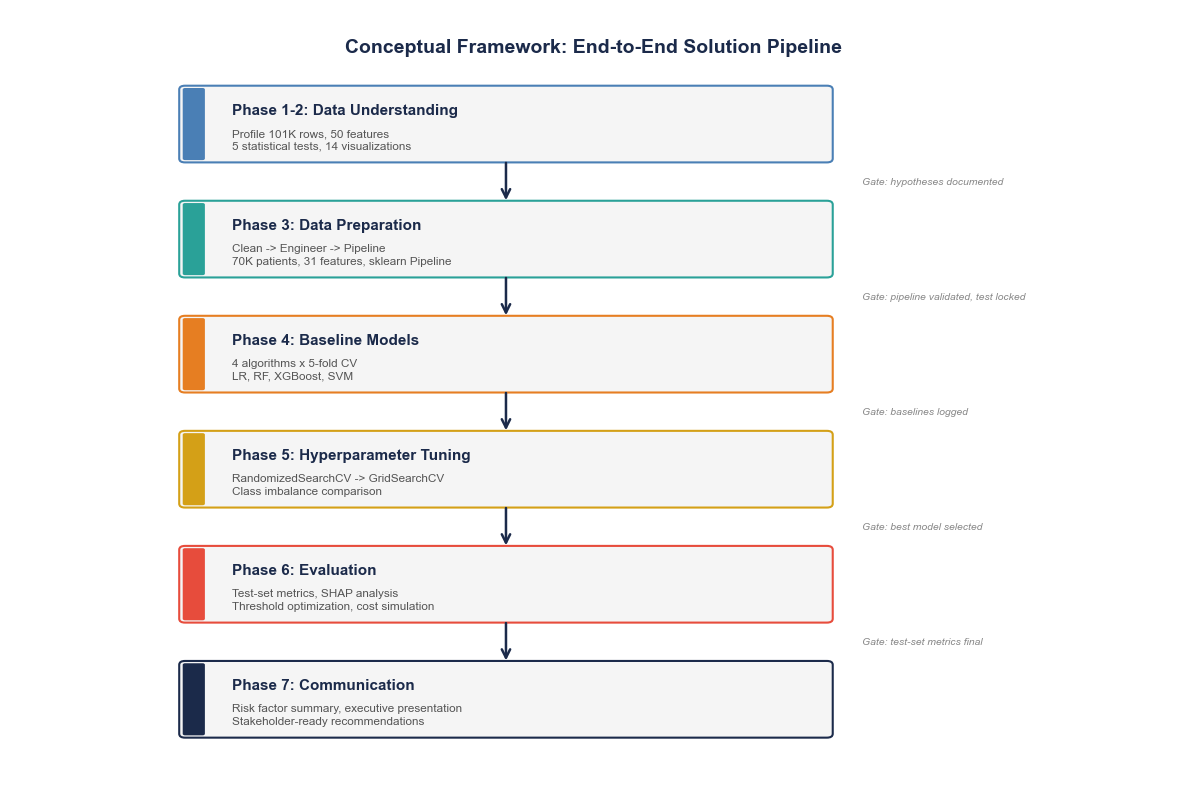

In [46]:
# Conceptual Framework -- End-to-end solution pipeline flowchart
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(12, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')

# Stage definitions: (label, detail, color_key, y_center)
stages = [
    ('Phase 1-2: Data Understanding',
     'Profile 101K rows, 50 features\n5 statistical tests, 14 visualizations',
     'steel', 8.5),
    ('Phase 3: Data Preparation',
     'Clean -> Engineer -> Pipeline\n70K patients, 31 features, sklearn Pipeline',
     'teal', 7.0),
    ('Phase 4: Baseline Models',
     '4 algorithms x 5-fold CV\nLR, RF, XGBoost, SVM',
     'orange', 5.5),
    ('Phase 5: Hyperparameter Tuning',
     'RandomizedSearchCV -> GridSearchCV\nClass imbalance comparison',
     'gold', 4.0),
    ('Phase 6: Evaluation',
     'Test-set metrics, SHAP analysis\nThreshold optimization, cost simulation',
     'red', 2.5),
    ('Phase 7: Communication',
     'Risk factor summary, executive presentation\nStakeholder-ready recommendations',
     'primary', 1.0),
]

# Gate labels between stages
gates = [
    'Gate: hypotheses documented',
    'Gate: pipeline validated, test locked',
    'Gate: baselines logged',
    'Gate: best model selected',
    'Gate: test-set metrics final',
]

box_width = 5.5
box_height = 0.9
box_left = 1.5
accent_width = 0.15

for label, detail, color_key, yc in stages:
    color = COLORS[color_key]

    # Main box (light fill)
    rect = mpatches.FancyBboxPatch(
        (box_left, yc - box_height / 2), box_width, box_height,
        boxstyle='round,pad=0.05', facecolor='#F5F5F5',
        edgecolor=color, linewidth=1.5
    )
    ax.add_patch(rect)

    # Left accent bar
    accent = mpatches.FancyBboxPatch(
        (box_left, yc - box_height / 2), accent_width, box_height,
        boxstyle='round,pad=0.02', facecolor=color,
        edgecolor=color, linewidth=0
    )
    ax.add_patch(accent)

    # Phase title (bold)
    ax.text(box_left + 0.4, yc + 0.18, label,
            fontsize=11, fontweight='bold', color=COLORS['primary'],
            va='center', ha='left')

    # Detail text
    ax.text(box_left + 0.4, yc - 0.2, detail,
            fontsize=8.5, color='#555555',
            va='center', ha='left', linespacing=1.3)

# Arrows between stages
for i in range(len(stages) - 1):
    y_start = stages[i][3] - box_height / 2 - 0.02
    y_end = stages[i + 1][3] + box_height / 2 + 0.02
    ax.annotate(
        '', xy=(box_left + box_width / 2, y_end),
        xytext=(box_left + box_width / 2, y_start),
        arrowprops=dict(arrowstyle='->', color=COLORS['primary'],
                        lw=1.8, mutation_scale=15)
    )

    # Gate annotation on the right
    gate_y = (y_start + y_end) / 2
    ax.text(box_left + box_width + 0.3, gate_y, gates[i],
            fontsize=7.5, fontstyle='italic', color='#888888',
            va='center', ha='left')

# Title
ax.text(5, 9.5, 'Conceptual Framework: End-to-End Solution Pipeline',
        fontsize=14, fontweight='bold', color=COLORS['primary'],
        va='center', ha='center')

plt.tight_layout()
plt.savefig('../figures/conceptual_framework.png', dpi=150, bbox_inches='tight')
plt.show()

The flowchart shows the complete pipeline from raw data to stakeholder communication, with validation gates between each phase. Each gate ensures the preceding phase produced valid output before proceeding -- for example, the pipeline must transform without errors before models are trained, and models must be selected on cross-validation before the test set is unlocked. This prevents cascading errors and ensures reproducibility.

### 💾 Save Phase 3 Artifacts

Save everything Phase 4 needs: cleaned data, train/test splits, fitted preprocessor, and feature lists.

In [ ]:
import joblib, pickle

# ── DataFrames ──────────────────────────────────────────────────
df_clean.to_parquet(f'{ARTIFACTS_DIR}/phase3_df_clean.parquet', index=False)
X_train.to_parquet(f'{ARTIFACTS_DIR}/phase3_X_train.parquet', index=False)
X_test.to_parquet(f'{ARTIFACTS_DIR}/phase3_X_test.parquet', index=False)
y_train.to_frame().to_parquet(f'{ARTIFACTS_DIR}/phase3_y_train.parquet', index=False)
y_test.to_frame().to_parquet(f'{ARTIFACTS_DIR}/phase3_y_test.parquet', index=False)

# ── Fitted preprocessor ─────────────────────────────────────────
joblib.dump(preprocessor, f'{ARTIFACTS_DIR}/phase3_preprocessor.joblib')

# ── Feature lists and metadata ──────────────────────────────────
phase3_meta = {
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'binary_features': binary_features,
    'all_features': numeric_features + categorical_features + binary_features,
    'target': target,
    'n_train': len(X_train),
    'n_test': len(X_test),
    'positive_rate_train': float(y_train.mean()),
    'positive_rate_test': float(y_test.mean()),
    'n_features_encoded': int(preprocessor.get_feature_names_out().shape[0]),
}
with open(f'{ARTIFACTS_DIR}/phase3_meta.pkl', 'wb') as f:
    pickle.dump(phase3_meta, f)

print('✅ Phase 3 artifacts saved:')
print(f'   phase3_df_clean.parquet    → {df_clean.shape}')
print(f'   phase3_X_train.parquet     → {X_train.shape}')
print(f'   phase3_X_test.parquet      → {X_test.shape}')
print(f'   phase3_y_train.parquet     → {y_train.shape}')
print(f'   phase3_y_test.parquet      → {y_test.shape}')
print(f'   phase3_preprocessor.joblib')
print(f'   phase3_meta.pkl            → feature lists + split stats')
